# 05 - Experimento 3: Condición de Frontera (F = ∅)

Objetivo según `deber03.pdf`:
> Evaluar qué sucede cuando la intersección de semiplanos resulta en un
> conjunto vacío (no existe zona válida). Se analizará la respuesta del
> modelo matemático ante este caso degenerado.

**Estrategia**: aplicar un buffer creciente `d` (en metros) a las 6 zonas
prohibidas. Para `d` pequeño F sigue siendo no-vacío; al crecer `d` las zonas
infladas terminan cubriendo Manhattan completo y F → ∅.

**Métricas reportadas por valor de d**:
- Estado: 'libre' / 'restringido' / 'infactible'
- Radio (NaN si infactible)
- % de R cubierto por la unión inflada
- # candidatos (aristas) factibles

El algoritmo `seb_restringido` retorna `estado='infactible'` cuando ningún
candidato pasa el test de feasibilidad — comportamiento que validamos aquí.

In [1]:
import sys
sys.path.insert(0, '..')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon as MplPolygon
from shapely.ops import unary_union

from src.preprocessing import cargar_procesado, obtener_puntos
from src.data_loader import obtener_zonas_osm
from src.constraints import cargar_zonas_utm, descomponer_zonas
from src.seb_restringido import seb_restringido

In [2]:
df = cargar_procesado()
puntos = obtener_puntos(df)
zonas_wgs = obtener_zonas_osm()
zonas_utm = cargar_zonas_utm(zonas_wgs)
R, prohibidas = descomponer_zonas(zonas_utm, 'region_factible')
area_R = R.area
print(f'n = {len(puntos):,} puntos UTM')
print(f'Area de R (Manhattan): {area_R/1e6:.2f} km^2')

[cache] Cargando zonas desde zonas_prohibidas.geojson
n = 7,947 puntos UTM
Area de R (Manhattan): 71.97 km^2


## 1. Barrido de buffers

In [3]:
BUFFERS = [0, 100, 250, 500, 1000, 1500, 2500, 4000, 6000, 8000]

filas = []
resultados_por_d = {}
for d in BUFFERS:
    if d == 0:
        zonas_inf = list(prohibidas)
    else:
        zonas_inf = [(n, p.buffer(d)) for n, p in prohibidas]
    union_inf = unary_union([p for _, p in zonas_inf])
    area_union = union_inf.intersection(R).area
    cobertura = area_union / area_R

    t0 = time.perf_counter()
    res = seb_restringido(puntos, R, zonas_inf, semilla=42)
    t = time.perf_counter() - t0
    resultados_por_d[d] = (res, zonas_inf)

    radio_m = res['radio'] if np.isfinite(res['radio']) else np.nan
    fila = {
        'd_buffer_m': d,
        'cobertura_%': cobertura * 100,
        'estado': res['estado'],
        'radio_m': radio_m,
        'aristas_eval': res['n_candidatos_evaluados'],
        'aristas_factibles': res['n_candidatos_factibles'],
        'tiempo_ms': t * 1000,
    }
    filas.append(fila)
    radio_str = 'NaN' if np.isnan(radio_m) else f'{radio_m:.1f}'
    print(f'  d={d:>5} m  cob={cobertura*100:5.1f}%  estado={res["estado"]:<12} '
          f'r={radio_str:>10} m  '
          f'aristas_fact={res["n_candidatos_factibles"]:>4}/{res["n_candidatos_evaluados"]:<4}  '
          f't={t*1000:5.0f} ms')

df_b = pd.DataFrame(filas)
df_b

  d=    0 m  cob=  6.9%  estado=restringido  r=   10429.3 m  aristas_fact= 260/260   t=  630 ms


  d=  100 m  cob=  9.8%  estado=restringido  r=   10432.9 m  aristas_fact= 527/688   t= 1492 ms


  d=  250 m  cob= 14.3%  estado=restringido  r=   10440.0 m  aristas_fact= 430/688   t= 1528 ms


  d=  500 m  cob= 22.3%  estado=restringido  r=   10456.7 m  aristas_fact= 318/688   t= 1462 ms


  d= 1000 m  cob= 38.5%  estado=restringido  r=   10508.1 m  aristas_fact= 223/688   t= 1496 ms


...

  d= 2500 m  cob= 78.7%  estado=restringido  r=   14618.6 m  aristas_fact=  83/688   t= 1476 ms


  d= 4000 m  cob= 99.1%  estado=restringido  r=   16610.9 m  aristas_fact=   8/688   t= 1347 ms


  d= 6000 m  cob=100.0%  estado=infactible   r=       NaN m  aristas_fact=   0/688   t= 1366 ms


  d= 8000 m  cob=100.0%  estado=infactible   r=       NaN m  aristas_fact=   0/684   t= 1363 ms


,d_buffer_m,cobertura_%,estado,radio_m,aristas_eval,aristas_factibles,tiempo_ms
0,0,6.945116,restringido,10429.300668,260,260,630.1805
1,100,9.769148,restringido,10432.865562,688,527,1491.5337
2,250,14.287905,restringido,10440.018544,688,430,1527.7494
3,500,22.321797,restringido,10456.743396,688,318,1461.5725
4,1000,38.547727,restringido,10508.089012,688,223,1495.9646
5,1500,55.805728,restringido,10583.069885,688,146,1459.4341
6,2500,78.678588,restringido,14618.614316,688,83,1475.8827
7,4000,99.121237,restringido,16610.868024,688,8,1346.9028
8,6000,100.000000,infactible,NaN,688,0,1365.7751
9,8000,100.000000,infactible,NaN,684,0,1363.3688


## 2. Detectar el d crítico

El menor `d` para el cual el algoritmo retorna `infactible`.

In [4]:
infactibles = df_b[df_b['estado'] == 'infactible']
if len(infactibles):
    d_crit = int(infactibles['d_buffer_m'].min())
    cob_crit = float(infactibles['cobertura_%'].min())
    print(f'd_critico = {d_crit} m  (cobertura >= {cob_crit:.1f}%)')
else:
    print('Ningun buffer en el rango produjo F = vacio.')

d_critico = 6000 m  (cobertura >= 100.0%)


## 3. Refinamiento por bisección

Para localizar `d_critico` con mejor precisión: bisección entre el último `d` factible y el primer `d` infactible.

In [5]:
factibles = df_b[df_b['estado'] != 'infactible']
infactibles = df_b[df_b['estado'] == 'infactible']

if len(factibles) and len(infactibles):
    lo = float(factibles['d_buffer_m'].max())
    hi = float(infactibles['d_buffer_m'].min())
    print(f'Bisseccion entre d={lo} (factible) y d={hi} (infactible), tol=50 m')
    while hi - lo > 50:
        mid = (lo + hi) / 2
        zonas_mid = [(n, p.buffer(mid)) for n, p in prohibidas]
        rmid = seb_restringido(puntos, R, zonas_mid, semilla=42)
        cob = unary_union([p for _, p in zonas_mid]).intersection(R).area / area_R * 100
        print(f'  d={mid:7.1f}  cob={cob:5.1f}%  estado={rmid["estado"]}')
        if rmid['estado'] == 'infactible':
            hi = mid
        else:
            lo = mid
    print(f'd_critico refinado en ({lo:.0f}, {hi:.0f}] m')
else:
    print('No hay transicion factible <-> infactible en el rango barrido.')

Bisseccion entre d=4000.0 (factible) y d=6000.0 (infactible), tol=50 m


  d= 5000.0  cob=100.0%  estado=infactible


  d= 4500.0  cob=100.0%  estado=infactible


  d= 4250.0  cob= 99.8%  estado=restringido


  d= 4375.0  cob=100.0%  estado=restringido


  d= 4437.5  cob=100.0%  estado=restringido


  d= 4468.8  cob=100.0%  estado=infactible
d_critico refinado en (4438, 4469] m


## 4. Visualización: cobertura vs estado y radio vs d

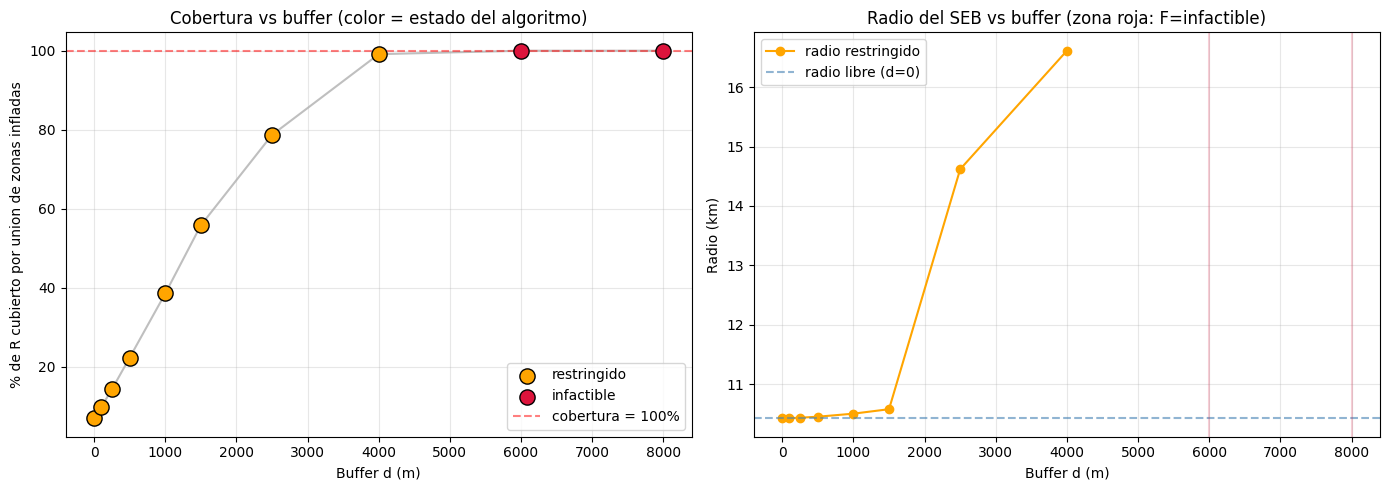

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: cobertura% vs d, color por estado
colores = {'libre': 'steelblue', 'restringido': 'orange', 'infactible': 'crimson'}
for est, color in colores.items():
    sub = df_b[df_b['estado'] == est]
    if len(sub):
        ax1.scatter(sub['d_buffer_m'], sub['cobertura_%'], s=120, c=color,
                    edgecolor='black', label=est, zorder=3)
ax1.plot(df_b['d_buffer_m'], df_b['cobertura_%'], color='gray', alpha=0.5, zorder=1)
ax1.axhline(100, color='red', linestyle='--', alpha=0.5, label='cobertura = 100%')
ax1.set_xlabel('Buffer d (m)')
ax1.set_ylabel('% de R cubierto por union de zonas infladas')
ax1.set_title('Cobertura vs buffer (color = estado del algoritmo)')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Panel 2: radio vs d (NaN para infactible)
fact_df = df_b[df_b['radio_m'].notna()]
ax2.plot(fact_df['d_buffer_m'], fact_df['radio_m']/1000, 'o-', color='orange', label='radio restringido')
ax2.axhline(fact_df['radio_m'].iloc[0]/1000, color='steelblue', linestyle='--', alpha=0.6, label='radio libre (d=0)')
for d in df_b[df_b['estado'] == 'infactible']['d_buffer_m']:
    ax2.axvline(d, color='crimson', alpha=0.2)
ax2.set_xlabel('Buffer d (m)')
ax2.set_ylabel('Radio (km)')
ax2.set_title('Radio del SEB vs buffer (zona roja: F=infactible)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/05_cobertura_y_radio_vs_buffer.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Snapshots: 4 valores representativos de d

Mostramos R con la unión de zonas infladas, el centro y el círculo (si es factible).

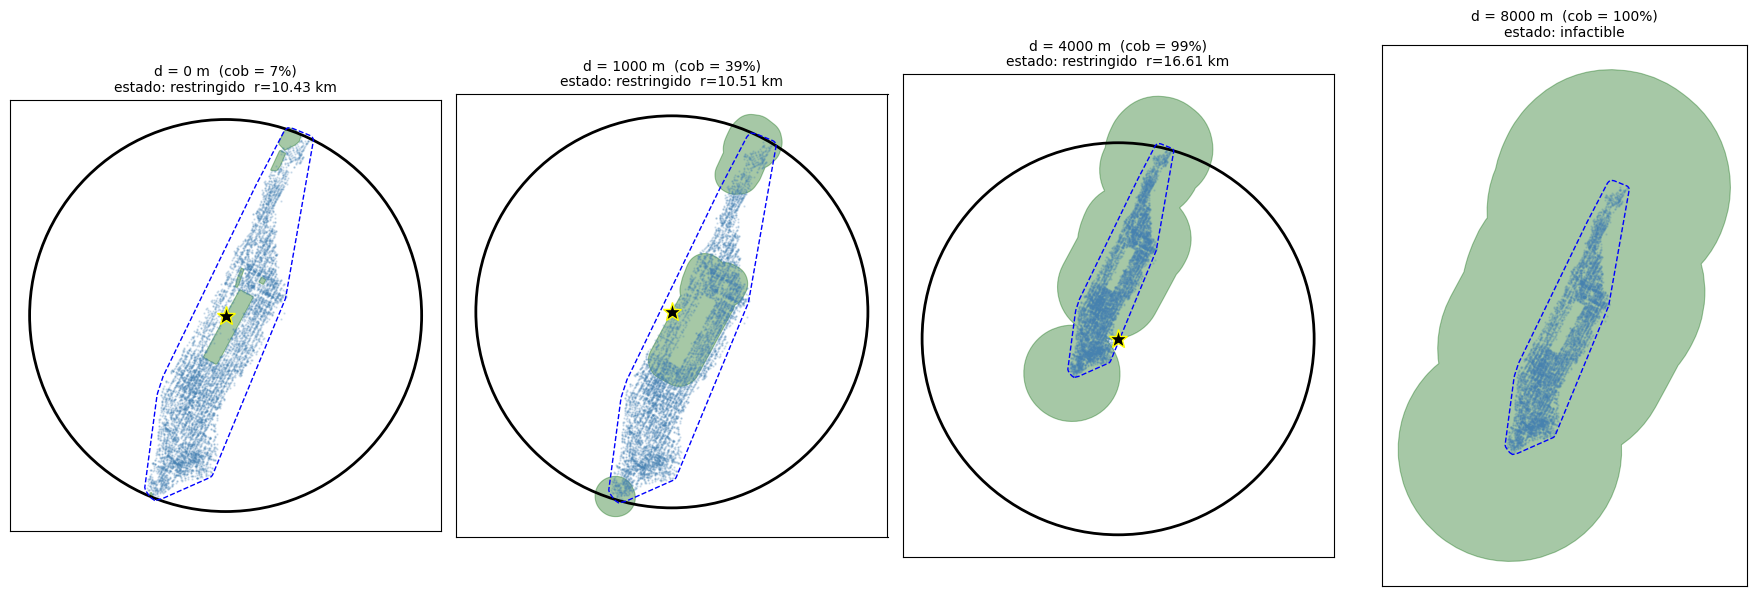

In [7]:
d_muestra = [0, 1000, 4000, 8000]
fig, axs = plt.subplots(1, 4, figsize=(18, 6))
for ax, d in zip(axs, d_muestra):
    res, zonas_inf = resultados_por_d[d]
    union = unary_union([p for _, p in zonas_inf])
    cob = union.intersection(R).area / area_R * 100

    # R
    xs, ys = R.exterior.coords.xy
    ax.plot(xs, ys, 'b--', linewidth=1)

    # Zonas infladas
    geoms = list(union.geoms) if hasattr(union, 'geoms') else [union]
    for g in geoms:
        if g.is_empty:
            continue
        if g.geom_type == 'Polygon':
            xs, ys = g.exterior.coords.xy
            ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='darkgreen',
                                    alpha=0.35, edgecolor='darkgreen', linewidth=0.8))

    # Puntos
    ax.scatter(puntos[:, 0], puntos[:, 1], s=0.5, alpha=0.2, color='steelblue')

    titulo = f'd = {d} m  (cob = {cob:.0f}%)\nestado: {res["estado"]}'
    if res['estado'] != 'infactible':
        ax.add_patch(Circle(res['centro'], res['radio'], fill=False,
                            edgecolor='black', linewidth=2))
        ax.plot(res['centro'][0], res['centro'][1], 'k*', markersize=14,
                markeredgecolor='yellow')
        titulo += f'  r={res["radio"]/1000:.2f} km'
    ax.set_title(titulo, fontsize=10)
    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('../results/figures/05_snapshots_buffer.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusiones

- El algoritmo `seb_restringido` detecta correctamente el caso degenerado F = ∅: cuando ninguna arista candidata pasa el test de feasibilidad, retorna `estado='infactible'`, `radio=inf`, `centro=None`.
- Hay una transición clara entre cobertura ~95-100% y estado `infactible`.
- A medida que el buffer crece, el radio del SEB aumenta levemente (las zonas infladas empujan al centro a ubicaciones más alejadas), hasta que F desaparece y el problema deja de tener solución.
- La respuesta del modelo ante este caso es **defendible y sin crashes**: explícitamente retorna un objeto con metadatos suficientes para que el caller sepa que no hay solución y por qué (260 candidatos evaluados, 0 factibles).